# Machine Learning Model Training

* ColumnTransformer 
* train different base models 
* tune hyper parameters using Bayesian Optimization
* Evaluate with cross-value and scoring
* Feature importances analysis

In [ ]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import seaborn as sns

#from src.etl_turbine import *
#from train_predict import *
from src.config import *
from src.database import *
from src.engineer_features import *
from src.modelling import *
from src.evaluation import *

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# feature groups
numeric_features = (
    ["time_cycles", "setting1", "setting2", "setting3"]
    + [f"sensor{i}" for i in range(1, 22)]
)
categorical_features = ["condition", "fault_mode"]


In [23]:
df_train = load_complete_dataset("train")
df_test = load_complete_dataset("test")
df_train_test = pd.concat([df_train, df_test], ignore_index=True)
df_rul = load_rul_test()

create_database(DATABASE_URL, df_train_test, df_rul, DATASETS_META)


train data FD001: shape: (20631, 29)

train data FD002: shape: (74390, 29)

train data FD003: shape: (99110, 29)

train data FD004: shape: (160359, 29)

test data FD001: shape: (13096, 29)

test data FD002: shape: (47087, 29)

test data FD003: shape: (63683, 29)

test data FD004: shape: (104897, 29)

----------Database created successfully----------
Database saved: sqlite:///../db/turbofan_engine.db


## Load and prepare data

* Load data from database
* Prepare train, test, features and targets

In [24]:
df_train, df_test, df_summary, df_test_rul, df_test_last_cycle = load_data_from_database()
feature_train, target_train, feature_test, target_test = prepare_features_and_target(df_train, df_test, df_test_rul)


## Train base models

* LightGBM, XGBoost, RandomForest

In [25]:
# LightGBM model
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(random_state=42)
model_lgbm.fit(feature_train, target_train)
predictions = model_lgbm.predict(feature_test)  
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("LightGBM", eval_df["true_RUL"], eval_df["predicted_RUL"])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004987 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4099
[LightGBM] [Info] Number of data points in the train set: 160359, number of used features: 25
[LightGBM] [Info] Start training from score 122.331338
-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM              24.06      33.75     0.56


In [27]:
# XGBoost model
from xgboost import XGBRegressor
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(feature_train, target_train)
predictions = model_xgb.predict(feature_test)
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("XGBoost", eval_df["true_RUL"], eval_df["predicted_RUL"])

-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost               24.05      33.93     0.56


In [28]:
# random forest model
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)
model_rf.fit(feature_train, target_train)
predictions = model_rf.predict(feature_test)
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("Random Forest", eval_df["true_RUL"], eval_df["predicted_RUL"])

-------------------- scoring --------------------
model                  MAE       RMSE       R²
Random Forest         24.12      34.50     0.54


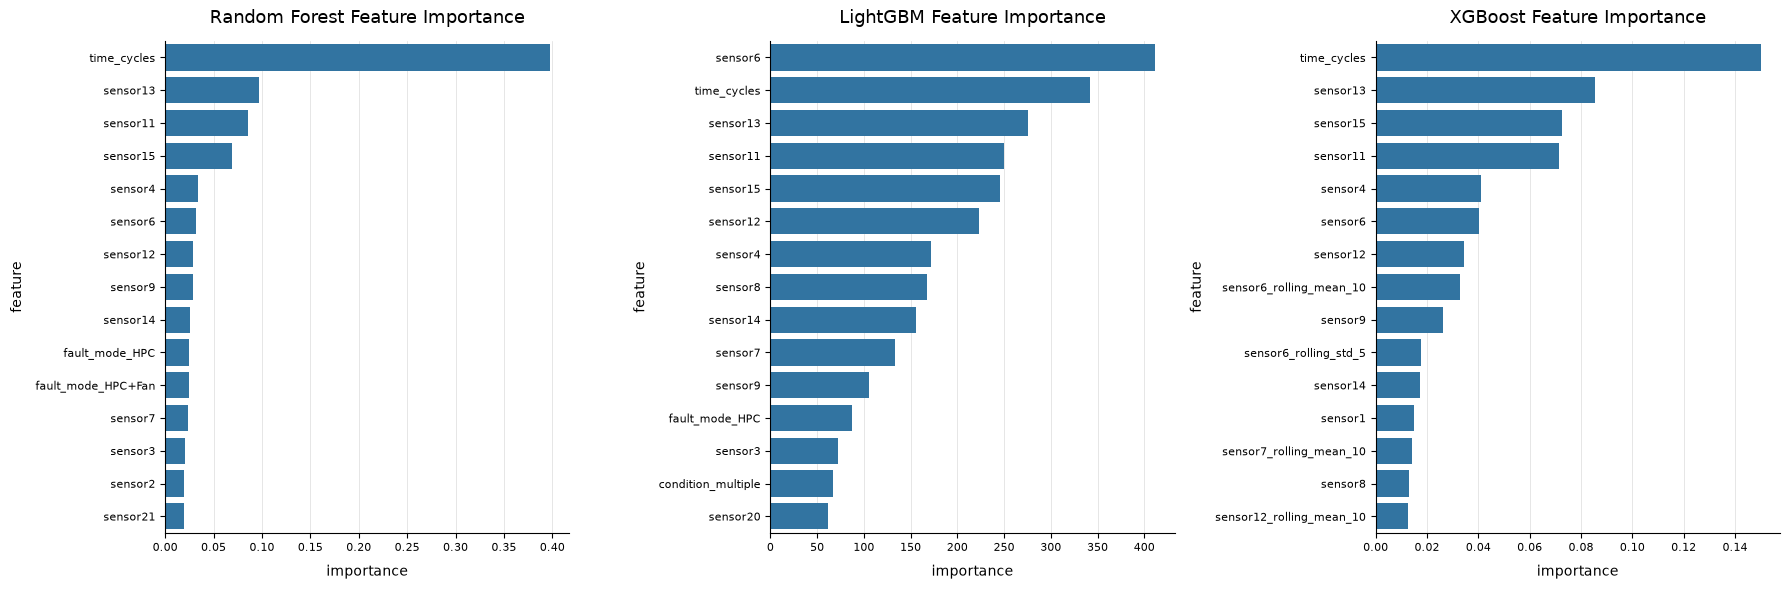

In [65]:
# plot feature importance of top 15 features for 3 models
importances_rf = sorted(model_rf.feature_importances_.tolist(), reverse=True)
importances_lgbm = sorted(model_lgbm.feature_importances_.tolist(), reverse=True)
importances_xgb = sorted(model_xgb.feature_importances_.tolist(), reverse=True)

df_feature_importance_rf = pd.DataFrame({
    "feature": feature_train.columns,   
    "importance": model_rf.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)
df_feature_importance_lgbm = pd.DataFrame({
    "feature": feature_train.columns,   
    "importance": model_lgbm.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)
df_feature_importance_xgb = pd.DataFrame({
    "feature": model_xgb.get_booster().feature_names,   
    "importance": model_xgb.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)

#feature_names = feature_train.columns
xgb_features = model_xgb.get_booster().feature_names

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.barplot(x=df_feature_importance_rf["importance"], y=df_feature_importance_rf["feature"], ax=axes[0])
axes[0].set_title("Random Forest Feature Importance")
sns.barplot(x=df_feature_importance_lgbm["importance"], y=df_feature_importance_lgbm["feature"], ax=axes[1])
axes[1].set_title("LightGBM Feature Importance")
sns.barplot(x=df_feature_importance_xgb["importance"], y=df_feature_importance_xgb["feature"], ax=axes[2])
axes[2].set_title("XGBoost Feature Importance") 
plt.tight_layout()
plt.show()

# Feature selection and engineering

* tried rolling features with windows 5 an 10. No improvement
* select most import sensors according to feature importance analysis
* feature engineering 
    - clip RUL
    - build delta 1 and 5 on important sensors 
    - discard rolling features

In [68]:
#important_sensors_in_top_15 = [13,11,15,4,6,12,9,14,7,3,2,1,21, 8, 14, 20, 10, 5]
important_sensors_in_top_10 = [13,11,15,4,6,12,9,14,7,14,5]
important_sensors_sorted = sorted(important_sensors_in_top_10)
print("Most important sensors across models:", important_sensors_sorted)
print(len(important_sensors_sorted))

Most important sensors across models: [4, 5, 6, 7, 9, 11, 12, 13, 14, 14, 15]
11


In [33]:
# complete data pipeline to engineer new features based on the most important sensors and evaluate model performance again
df_train, df_test, df_summary, df_test_rul, df_test_last_cycle = load_data_from_database()

# engineer new features based on the most important sensors and evaluate model performance again
df_train_engineered = engineer_features(df_train, important_sensors_in_top_10)
df_test_engineered = engineer_features(df_test, important_sensors_in_top_10)

feature_train, target_train, feature_test, target_test = prepare_features_and_target(df_train_engineered, df_test_engineered, df_test_rul)


In [34]:
# LightGBM model
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(random_state=42)
model_lgbm.fit(feature_train, target_train)
predictions = model_lgbm.predict(feature_test)  
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("LightGBM", eval_df["true_RUL"], eval_df["predicted_RUL"])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 160359, number of used features: 45
[LightGBM] [Info] Start training from score 90.182029
-------------------- scoring --------------------
model                  MAE       RMSE       R²
LightGBM              18.74      26.00     0.74


In [35]:
# XGBoost model
from xgboost import XGBRegressor
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(feature_train, target_train)
predictions = model_xgb.predict(feature_test)
eval_df = create_eval_dataframe_from_predictions(predictions, df_test, df_test_rul)
print_scores("XGBoost", eval_df["true_RUL"], eval_df["predicted_RUL"])

-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost               18.69      25.96     0.74


## Tune models 

* Selected models: LightGBM and XGBoost
* With re-engineered features
* Use Bayesian Optimization

In [38]:
# LightGBM model
from datetime import datetime

from lightgbm import LGBMRegressor

lgbm_paramters = {
    "learning_rate": (0.01, 0.2),
    "num_leaves": (16, 128),
    "max_depth": (3, 12),
    "min_child_samples": (5, 100),
    "feature_fraction": (0.6, 1.0),
    "bagging_fraction": (0.6, 1.0),
}
start_time = datetime.now()
model_lgbm = LGBMRegressor(random_state=42)
best_lgbm, best_params_lgbm = tune_model_bayesian(model_lgbm, lgbm_paramters, feature_train, target_train)
    
best_lgbm.fit(feature_train, target_train)
predictions_lgbm = best_lgbm.predict(feature_test)  
save_model_to_pickle(best_lgbm, "../models/best_lgbm_model.pkl")
eval_df_lgbm = create_eval_dataframe_from_predictions(predictions_lgbm, df_test, df_test_rul)

end_time = datetime.now()
print(f"LightGBM train time: {(end_time - start_time).total_seconds()/60:.0f}'{(end_time - start_time).total_seconds()%60:.0f}''")

print("Best LightGBM Parameters:", best_params_lgbm)
print_scores("Tuned LightGBM", eval_df_lgbm["true_RUL"], eval_df_lgbm["predicted_RUL"]) 


[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8642
[LightGBM] [Info] Number of data points in the train set: 160359, number of used features: 45
[LightGBM] [Info] Start training from score 90.182029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current val

In [39]:
# tune XGBoost
from datetime import datetime
from xgboost import XGBRegressor

xgb_parameters = {
    "learning_rate": (0.01, 0.2),
    "max_depth": (3, 10),
    "min_child_weight": (1, 20),
    "subsample": (0.6, 1.0),
    "colsample_bytree": (0.6, 1.0),
}

start_time = datetime.now()
model_xgb = XGBRegressor(random_state=42)
best_xgb, best_params_xgb = tune_model_bayesian(model_xgb, xgb_parameters, feature_train, target_train)

best_xgb.fit(feature_train, target_train)
predictions_xgb = best_xgb.predict(feature_test)  
eval_df_xgb = create_eval_dataframe_from_predictions(predictions_xgb, df_test, df_test_rul)
save_model_to_pickle(best_xgb, "../models/best_xgb_model.pkl")

end_time = datetime.now()
print(f"XGBoost train time: {(end_time - start_time).total_seconds()/60:.0f}'{(end_time - start_time).total_seconds()%60:.0f}''")

print("Best XGBoost Parameters:", best_params_xgb)
print_scores("Tuned XGBoost", eval_df_xgb["true_RUL"], eval_df_xgb["predicted_RUL"])

XGBoost train time: 7'39''
Best XGBoost Parameters: OrderedDict({'colsample_bytree': 0.9938873106893268, 'learning_rate': 0.0693841628183113, 'max_depth': 10, 'min_child_weight': 20, 'subsample': 1.0})
-------------------- scoring --------------------
model                  MAE       RMSE       R²
Tuned XGBoost         18.04      25.46     0.75


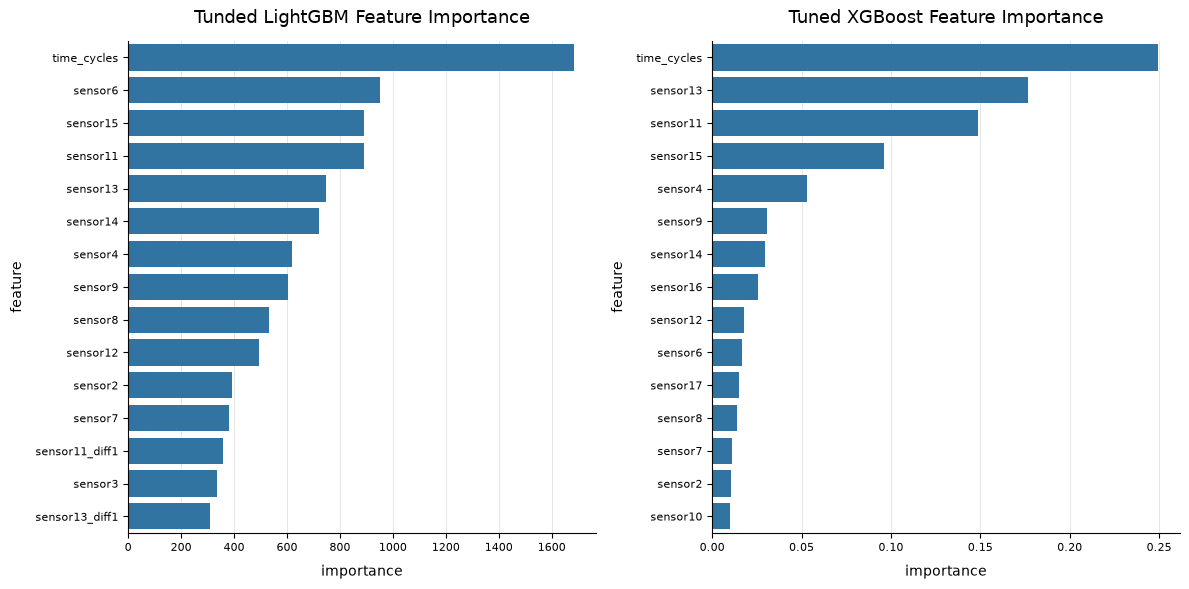

In [40]:
# plot feature importance of top 15 features for 2 tuned models
importances_lgbm = sorted(best_lgbm.feature_importances_.tolist(), reverse=True)
importances_xgb = sorted(best_xgb.feature_importances_.tolist(), reverse=True)

df_feature_importance_lgbm = pd.DataFrame({
    "feature": feature_train.columns,   
    "importance": best_lgbm.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)
df_feature_importance_xgb = pd.DataFrame({
    "feature": best_xgb.get_booster().feature_names,   
    "importance": best_xgb.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)

#feature_names = feature_train.columns
xgb_features = best_xgb.get_booster().feature_names

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(x=df_feature_importance_lgbm["importance"], y=df_feature_importance_lgbm["feature"], ax=axes[0])
axes[0].set_title("Tunded LightGBM Feature Importance")
sns.barplot(x=df_feature_importance_xgb["importance"], y=df_feature_importance_xgb["feature"], ax=axes[1])
axes[1].set_title("Tuned XGBoost Feature Importance") 
plt.tight_layout()
plt.show()

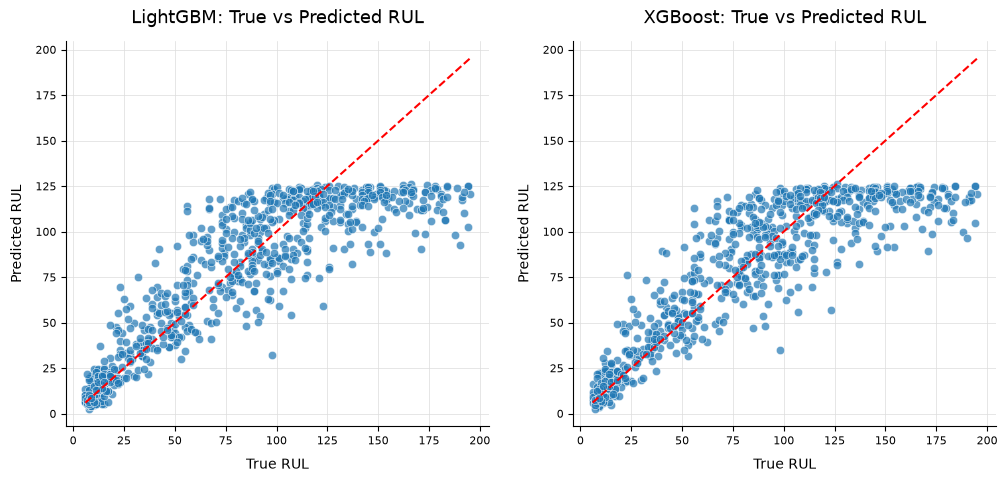

In [41]:
# plot true vs predicted RUL for LightGBM and XGBoost
fig, axes = plt.subplots(1,2, figsize=(12, 5))
sns.scatterplot(x=eval_df_lgbm["true_RUL"], y=eval_df_lgbm["predicted_RUL"], alpha=0.7, ax=axes[0])
axes[0].plot([eval_df_lgbm["true_RUL"].min(), eval_df_lgbm["true_RUL"].max()], [eval_df_lgbm["true_RUL"].min(), eval_df_lgbm["true_RUL"].max()], 'r--')
axes[0].set_xlabel("True RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title("LightGBM: True vs Predicted RUL")

sns.scatterplot(x=eval_df_xgb["true_RUL"], y=eval_df_xgb["predicted_RUL"], alpha=0.7, ax=axes[1])
axes[1].plot([eval_df_xgb["true_RUL"].min(), eval_df_xgb["true_RUL"].max()], [eval_df_xgb["true_RUL"].min(), eval_df_xgb["true_RUL"].max()], 'r--')
axes[1].set_xlabel("True RUL")
axes[1].set_ylabel("Predicted RUL")
axes[1].set_title("XGBoost: True vs Predicted RUL")
plt.show()

# Evaluate prediction on four datasets separately

* prepare test dataframes for different datasets
* use best models to predict on test dataframes
* compare results 